This notebook was created by Donyl Alcantara

# Network Topology of Reddit

## Section 1: Environment Configuration

#### 1.1 Environment Setup

In [39]:
import pandas as pd
import re
import zstandard as zstd
import io
import orjson
from collections import defaultdict
import json
from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt
import csv
import polars as pl
import os
import gdown
import numpy as np
import seaborn as sns
from statsmodels.distributions.empirical_distribution import ECDF
from pathlib import Path
import powerlaw
import mapclassify
from scipy.sparse import csr_matrix
from scipy import sparse
import scipy.sparse as sp

#### 1.2 Import `user_subreddit_interactions` from `analytics`

In [2]:
df_all = pl.scan_parquet('analytics/user_subreddit_interactions.parquet').collect()
df_all 

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Important_Trash_4555""","""povertyfinance""",0,16,16
"""Shatter_starx""","""pcmasterrace""",0,22,22
"""geeriveting""","""reddeadredemption""",0,1,1
"""Japparbyn""","""interestingasfuck""",0,1,1
"""BlackAbsol44""","""pcmasterrace""",1,0,1
…,…,…,…,…
"""spoonyF0rky01""","""news""",0,6,6
"""outsidewrld1""","""dating_advice""",1,0,1
"""SweetSoberCaroline""","""askreddit""",0,1,1


## Section 2: Data Pre-Processing/Exploratory Data Analysis

According to [Jakobsen (2022)](https://blog.bruun.dev/exploring-reddit-community-relations-with-graphs-and-neo4j/), due to the existence of significant noise, including the possibility of repeated interactions, specifically because of 'bot users,' we initially do the following: 

- Normalize subreddit names (done in 00)
- Filter self-referential interactions 
- Remove interactions made by top 2% users
- Remove single-interaction subreddit pairs
- Merge interactions between subreddit pairs


#### 2.1 User Activity Aggregation

In [3]:
# total interaction per author 

df_author_interaction = df_all.group_by('author').agg(
    pl.col("interaction_count").sum().alias('interaction_per_user')).sort(
    'interaction_per_user', descending=True) # convert into eager df

# create rank col
df_author_interaction = df_author_interaction.with_columns(pl.arange(
    1, df_author_interaction.height + 1).alias("rank")) # height = number of rows, width = number of cols

df_author_interaction.head(20)

author,interaction_per_user,rank
str,i64,i64
"""donut-bot""",163298,1
"""TipOfTheirTongue""",162697,2
"""VisualMod""",100202,3
"""MinecraftModBot""",89755,4
"""MrPuma86""",65225,5
…,…,…
"""Sky-876""",20904,16
"""bvandepol""",20343,17
"""AskWomen-ModTeam""",20105,18


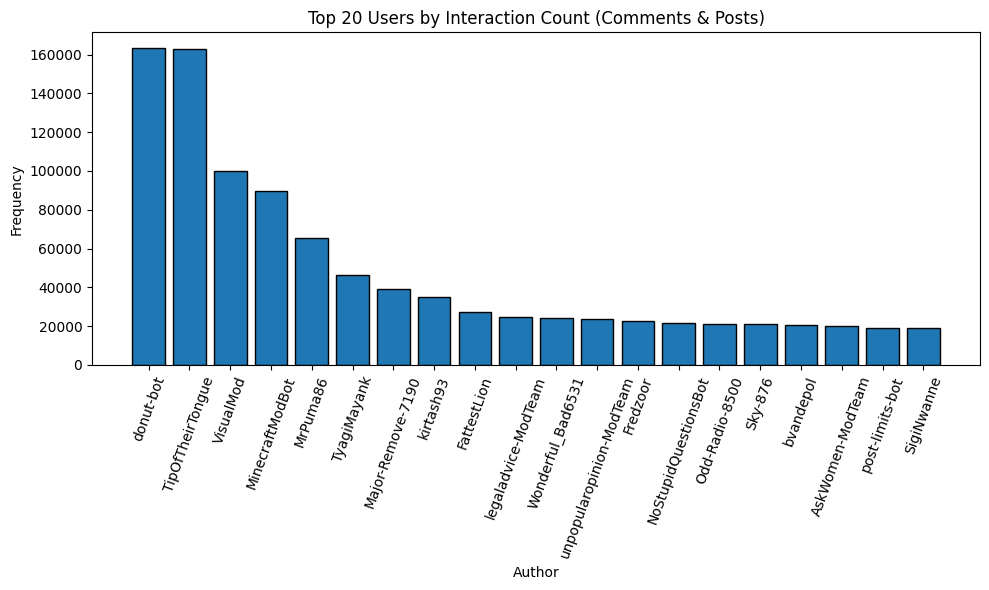

In [4]:
# top 20 

# bar graph
plt.figure(figsize=(10, 6))
plt.bar(df_author_interaction['author'].head(20),
        df_author_interaction['interaction_per_user'].head(20),
        edgecolor='black')
plt.title("Top 20 Users by Interaction Count (Comments & Posts)")
plt.xlabel("Author")
plt.ylabel("Frequency")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

#### 2.2 Rank-Frequency Profiling

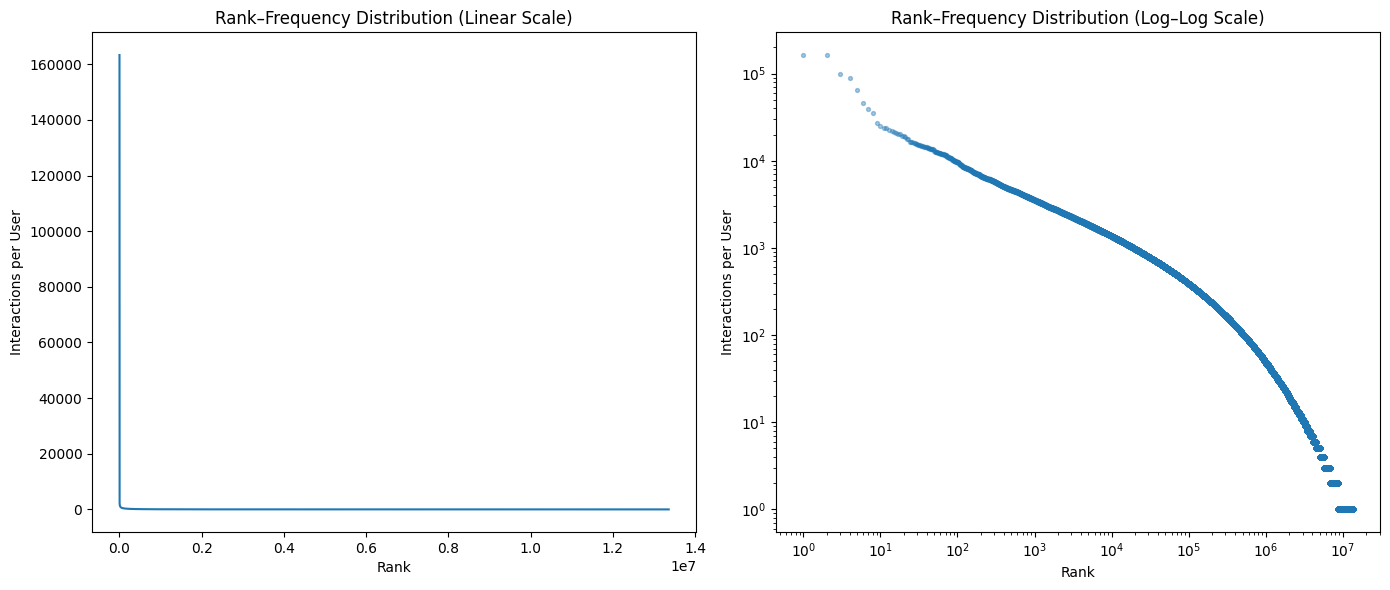

In [5]:
# visualize the long-tail dist with and without scaling
# convert polars series to numpy
x = df_author_interaction['rank'].to_numpy()
y = df_author_interaction['interaction_per_user'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Linear scale
axes[0].plot(x, y)
axes[0].set_title("Rank–Frequency Distribution (Linear Scale)")
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Interactions per User")

# Log–Log scale
axes[1].scatter(x, y, alpha=0.4, s=8, color='#1f77b4')
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Rank–Frequency Distribution (Log–Log Scale)")
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("Interactions per User")

plt.tight_layout()
plt.show()

#### 2.3 Outlier/Noise Detection 

#### Log Interquartile Range (IQR)

In [95]:
data = df_author_interaction["interaction_per_user"].to_numpy()
log_data = np.log1p(data)

Q1 = np.percentile(log_data, 25)
Q3 = np.percentile(log_data, 75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = data[log_data > upper_bound]

print(f"Outlier threshold: {np.expm1(upper_bound):.0f}")

Outlier threshold: 111


#### Contribution Share

The distribution of user activity exhibits a pronounced long-tail. We observe a high concentration of activity among a small subset of users: the top 2% of contributors account for approximately 47% of all interactions. This extreme inequality suggests that a small number of highly active users disproportionately shape the interaction network. To mitigate this bias and reduce potential noise from automated or hyperactive accounts, we remove users whose interaction counts fall within the top 2% of the distribution.

In [7]:
# sort descending
df_cs = df_author_interaction.sort("interaction_per_user", descending=True)
total_interactions = df_cs["interaction_per_user"].sum()

# iterate over top 1 to 20%
for pct in range(1, 21):
    n_top = int(df_cs.height * (pct/100))
    top_users = df_cs.head(n_top)
    share = top_users["interaction_per_user"].sum() / total_interactions
    print(f"Top {pct}% users: {n_top}, Contribution share: {share:.2f}")

Top 1% users: 133614, Contribution share: 0.35
Top 2% users: 267228, Contribution share: 0.47
Top 3% users: 400842, Contribution share: 0.55
Top 4% users: 534456, Contribution share: 0.60
Top 5% users: 668070, Contribution share: 0.65
Top 6% users: 801684, Contribution share: 0.68
Top 7% users: 935298, Contribution share: 0.71
Top 8% users: 1068912, Contribution share: 0.74
Top 9% users: 1202526, Contribution share: 0.76
Top 10% users: 1336140, Contribution share: 0.77
Top 11% users: 1469754, Contribution share: 0.79
Top 12% users: 1603368, Contribution share: 0.81
Top 13% users: 1736983, Contribution share: 0.82
Top 14% users: 1870597, Contribution share: 0.83
Top 15% users: 2004211, Contribution share: 0.84
Top 16% users: 2137825, Contribution share: 0.85
Top 17% users: 2271439, Contribution share: 0.86
Top 18% users: 2405053, Contribution share: 0.86
Top 19% users: 2538667, Contribution share: 0.87
Top 20% users: 2672281, Contribution share: 0.88


#### Lorenz Curve and Gini Coefficient

The Gini coefficient of user interactions is 0.83, indicating extreme inequality. The top 2% of users generate 47% of all interactions, confirming that a small subset of highly active users dominates the network. To reduce the influence of these extreme contributors, we remove users within the top 2% of the distribution.

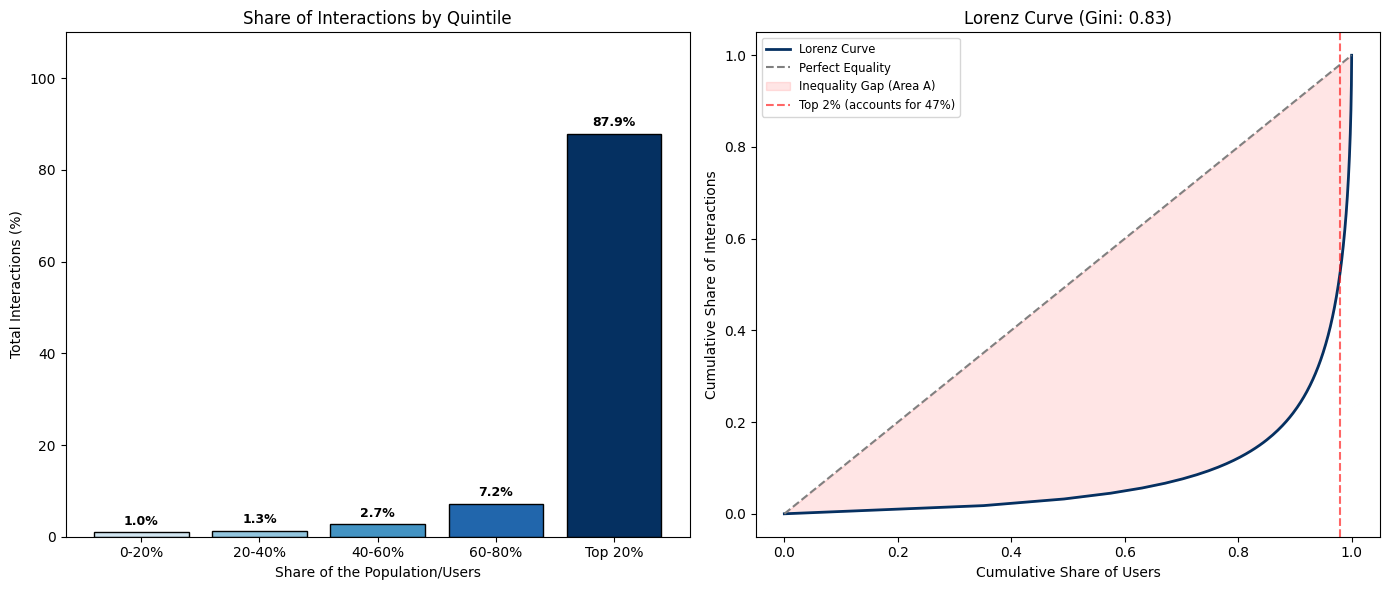

In [8]:
y_sorted = np.sort(df_author_interaction["interaction_per_user"].to_numpy())
total_val = y_sorted.sum()
n_users = len(y_sorted)

# lorenz data
cum_users = np.arange(1, n_users + 1) / n_users
cum_activity = np.cumsum(y_sorted) / total_val
gini = 1 - 2 * np.sum((cum_activity[1:] + cum_activity[:-1]) * np.diff(cum_users) / 2)

# quintile data
groups = np.array_split(y_sorted, 5)
shares = [(g.sum() / total_val) * 100 for g in groups]
quintile_labels = ['0-20%', '20-40%', '40-60%', '60-80%', 'Top 20%']
colors = ['#d1e5f0', '#92c5de', '#4393c3', '#2166ac', '#053061']

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Quintile Bar Chart
bars = ax1.bar(quintile_labels, shares, color=colors, edgecolor='black')
ax1.set_title('Share of Interactions by Quintile')
ax1.set_ylabel('Total Interactions (%)')
ax1.set_xlabel('Share of the Population/Users')
ax1.set_ylim(0, 110)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# Lorenz Curve
ax2.plot(cum_users, cum_activity, label='Lorenz Curve', color='#053061', linewidth=2)
ax2.plot([0,1], [0,1], linestyle='--', color='grey', label='Perfect Equality')
ax2.fill_between(cum_users, cum_activity, cum_users, color='red', alpha=0.1, label='Inequality Gap (Area A)')

# threshold 
ax2.axvline(cum_users[int(len(y_sorted) * 0.98)], linestyle='--', color='r', alpha=0.6, label=f'Top 2% (accounts for {(1-cum_activity[int(len(y_sorted) * 0.98)])*100:.0f}%)')
ax2.set_title(f'Lorenz Curve (Gini: {gini:.2f})')
ax2.set_xlabel('Cumulative Share of Users')
ax2.set_ylabel('Cumulative Share of Interactions')
ax2.legend(loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

#### 98th Percentile vs. Power-law xmin

Calculating best minimal value for power law fit


Fitting xmin: 100%|█████████████████████████| 4101/4101 [06:01<00:00, 11.35it/s]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


Top 2% threshold: 185.00
Power-law xmin: 622.00


/var/folders/_g/nz39y46d1l93yjn3vj6_jd100000gn/T/ipykernel_22530/1656712637.py:42: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


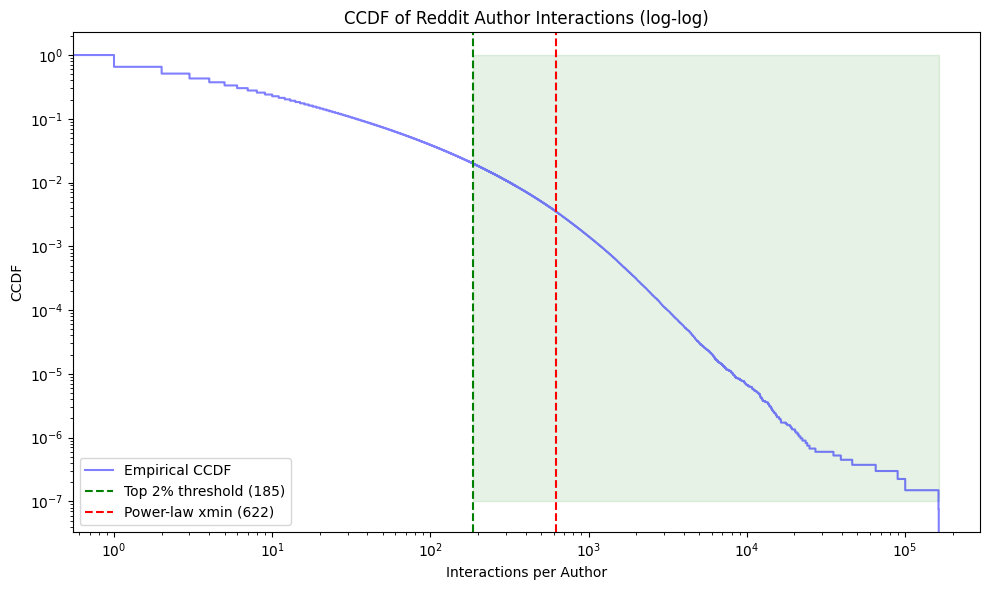

In [96]:
# Data
data = df_author_interaction["interaction_per_user"].to_numpy()

# Compute thresholds
# 98th percentile
threshold_2pct = np.percentile(data, 98)

# Power law params
fit = powerlaw.Fit(data) 
alpha = fit.power_law.alpha
xmin = fit.power_law.xmin

print(f"Top 2% threshold: {threshold_2pct:.2f}")
print(f"Power-law xmin: {xmin:.2f}")

# Compute ECDF and CCDF
ecdf = ECDF(data)
ccdf = 1 - ecdf.y  # CCDF = 1 - CDF

# plot CCDF
plt.figure(figsize=(10,6))
plt.step(ecdf.x, ccdf, where='post', color='blue', alpha=0.5, label='Empirical CCDF')
plt.xscale('log')  # log-log scale
plt.yscale('log')

# threshold lines
plt.axvline(threshold_2pct, color='green', linestyle='--',  
            label=f'Top 2% threshold ({threshold_2pct:.0f})')
plt.axvline(xmin, color='red', linestyle='--',
            label=f'Power-law xmin ({xmin:.0f})')

# shade the top 2%
plt.fill_betweenx(y=[1e-7, 1], x1=threshold_2pct, x2=ecdf.x.max(),
                  color='green', alpha=0.1)

# labels
plt.xlabel("Interactions per Author")
plt.ylabel("CCDF")
plt.title("CCDF of Reddit Author Interactions (log-log)")
# plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [97]:
# Compare Power Law vs. Log-normal
R, p = fit.distribution_compare('power_law', 'lognormal')

print(f"Loglikelihood ratio (R): {R:.2f}")
print(f"p-value: {p:.4f}")

if p < 0.05:
    if R > 0:
        print("Conclusion: Reject H0. Power Law is a significantly better fit.")
    else:
        print("Conclusion: Reject H0. Log-normal is a significantly better fit.")
else:
    print("Conclusion: Fail to reject H0. Neither distribution is significantly better.")

Loglikelihood ratio (R): -198.21
p-value: 0.0000
Conclusion: Reject H0. Log-normal is a significantly better fit.


Log-normal parameters: mu=3.15, sigma=1.45


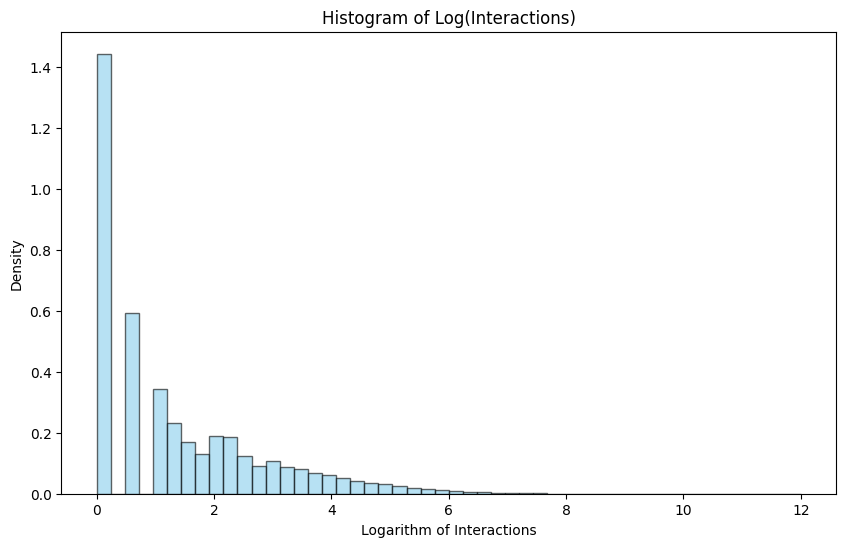

In [98]:
# Extract parameters from the fit
mu = fit.lognormal.mu
sigma = fit.lognormal.sigma

print(f"Log-normal parameters: mu={mu:.2f}, sigma={sigma:.2f}")

# Verification: Plot the histogram of the LOG of the data
log_data = np.log(data[data > 0])
plt.figure(figsize=(10, 6))
plt.hist(log_data, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.title('Histogram of Log(Interactions)')
plt.xlabel('Logarithm of Interactions')
plt.ylabel('Density')
plt.show()

## Section 3: Data Filtration

#### 3.1 Detecting Hyperactive Users (bots or anamalous values)

In [12]:
# get the top 2% df to detect bots and extreme users

threshold_filter = df_author_interaction.select(pl.col('interaction_per_user').quantile(0.98)).item()

df_top_users = df_author_interaction.filter(
    pl.col('interaction_per_user') > threshold_filter).select('author')

display(df_top_users)
print(f'98th Percentile: {threshold_filter}')

author
str
"""donut-bot"""
"""TipOfTheirTongue"""
"""VisualMod"""
"""MinecraftModBot"""
"""MrPuma86"""
…
"""MRHubrich"""
"""ForgetTheRuralJuror"""
"""Wide_Ordinary4078"""


98th Percentile: 185.0


In [13]:
# sanity check 
top_users_count = df_top_users.height
total_users = df_author_interaction.height
pct = top_users_count / total_users
print(f'{pct:.4f}')

0.0200


In [14]:
# remove top 2%

auti_wo_top = df_author_interaction.join(
    df_top_users,
    on='author',
    how='anti').sort('rank', descending=False)

auti_wo_top

author,interaction_per_user,rank
str,i64,i64
"""travprev""",185,266712
"""SmurfetteIsAussie""",185,266713
"""BlackfaceBunghole""",185,266714
"""theglorybox""",185,266715
"""angrokitten""",185,266716
…,…,…
"""FredbearAndMemes""",1,13361404
"""Fireremnant5""",1,13361405
"""ApplicationOk4584""",1,13361406


In [15]:
# display reconciled without hyperactive users

df_all_wo_top = df_all.join(
    auti_wo_top.select("author"),
    on="author",
    how="inner"
)

display(df_all_wo_top)

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Important_Trash_4555""","""povertyfinance""",0,16,16
"""geeriveting""","""reddeadredemption""",0,1,1
"""Japparbyn""","""interestingasfuck""",0,1,1
"""BlackAbsol44""","""pcmasterrace""",1,0,1
"""One-Personality3513""","""houseofthedragon""",2,1,3
…,…,…,…,…
"""spoonyF0rky01""","""news""",0,6,6
"""outsidewrld1""","""dating_advice""",1,0,1
"""SweetSoberCaroline""","""askreddit""",0,1,1


#### 3.2 Detecting Inactive Users

#### Frequency Distribution Table

In [16]:
# number of users for each interaction_per_user (least active to most active)

interaction_per_user_count = (
    auti_wo_top.group_by("interaction_per_user")
    .len()
    .rename({"len": "user_count"})
    .sort("interaction_per_user")
)

interaction_per_user_count = interaction_per_user_count.with_columns((
    (pl.col('user_count') / pl.col('user_count').sum()) * 100).alias('pct (%)'))

interaction_per_user_count.head(10)

interaction_per_user,user_count,pct (%)
i64,u32,f64
1,4627336,35.337481
2,1896163,14.480389
3,1099410,8.395841
4,739755,5.649272
5,539538,4.120279
6,414583,3.166037
7,331496,2.531529
8,271888,2.076321
9,228556,1.745409


#### Head–Tail Breaks for Identifying Inactive Users

To identify inactive Reddit users, the **Head–Tail Breaks (HTB)** algorithm [(Jiang et al., 2013)](https://arxiv.org/abs/1102.1561) was applied to the distribution of total user interactions (`interaction_per_user`). HTB is designed for **heavy-tailed distributions**, where many observations are small and a small minority are large, a pattern pervasive in online participation data.

The method partitions the distribution around the **mean value** into:

- **Head:** values greater than the mean  
- **Tail:** values less than or equal to the mean  

The weighted mean is computed as:

$$
\mu = \frac{\sum (x_i f_i)}{\sum f_i}
$$

where $x_i$ is the number of interactions and $f_i$ is the number of users with that interaction count.

In our case, only the **first HTB iteration** was used to identify the initial separation between low-activity and more active users. Users with interaction counts **below the first mean threshold** were classified as inactive and removed.

Using HTB renders a **data-driven threshold** for filtering minimally active or “drive-by” users, reducing noise and sparsity before constructing the **user–subreddit incidence matrix**.

In [17]:
# head-tail breaks algorithm 

def find_head_tail_break(data):
    current_data = data  # interaction_per_user = value (X)
    iteration = 1    # user_count = frequency (Y)
    
    while True:
        # get weighted mean: (value * frequency) / total frequency
        total_val = (current_data["interaction_per_user"] * current_data["user_count"]).sum()
        total_freq = current_data["user_count"].sum()
        mu = total_val / total_freq
        
        # head = those strictly above the mean
        head = current_data.filter(pl.col("interaction_per_user") > mu)
        
        # calculate percentage of users remaining in head
        head_percentage = head["user_count"].sum() / total_freq
        
        print(f"Iteration {iteration}: Mean = {mu:.2f}, Head % = {head_percentage:.2%}")
        
        # If the head is no longer a small minority (<40%), 
        # or we run out of data, the current mean is our natural threshold.
        if head_percentage > 0.40 or head.height == 0:
            final_threshold = round(mu)
            print(f"\nRESULT")
            print(f"Natural Mathematical Threshold: {final_threshold}")
            return final_threshold
            
        current_data = head
        iteration += 1

# Execute
final_threshold = find_head_tail_break(interaction_per_user_count)

Iteration 1: Mean = 10.78, Head % = 21.00%
Iteration 2: Mean = 41.01, Head % = 31.76%
Iteration 3: Mean = 84.52, Head % = 39.71%
Iteration 4: Mean = 123.40, Head % = 44.17%

RESULT
Natural Mathematical Threshold: 123


In [18]:
# implement head-tail algo using mapclassify lib (sanity check)

interaction_per_user = auti_wo_top["interaction_per_user"].to_numpy()
htb = mapclassify.HeadTailBreaks(interaction_per_user)
count = htb.counts
bins = htb.bins

df_htb = pd.DataFrame({'count (users)': count,
                       'bins (upper bound)': np.round(bins, 2)})

df_htb['class'] = pd.Series(np.arange(1, 13))
df_htb = df_htb[['class', 'count (users)', 'bins (upper bound)']]
df_htb = df_htb.set_index('class')
display(df_htb)

low_activity_thres = df_htb['bins (upper bound)'][1]
print(f'Remove inactive users/first class: < {low_activity_thres:.0f}')
# interpretation: 
# class 1 - Users with interaction_per_user ≤ 10.78 → 10,344,424 users
# class 2 → 10.78 < users ≤ 41.01 → low activity
# class 3 → 41.01 < users ≤ 84.52 → medium activity
# class 4 → 84.52 < users ≤ 123.40 → head (active)

,count (users),bins (upper bound)
class,,
1,10344424,10.78
2,1876882,41.01
3,526589,84.52
4,193626,123.40
5,80868,150.66
6,36556,166.87
7,17659,175.71
8,9373,180.39
9,3599,182.96


Remove inactive users/first class: < 11


In [19]:
# get initially cleaned df without hyperactive ones to filter out inactive ones 
# threshold = > 10 interactions

auti_cleaned = auti_wo_top.filter(pl.col('interaction_per_user') > low_activity_thres)
auti_cleaned

author,interaction_per_user,rank
str,i64,i64
"""travprev""",185,266712
"""SmurfetteIsAussie""",185,266713
"""BlackfaceBunghole""",185,266714
"""theglorybox""",185,266715
"""angrokitten""",185,266716
…,…,…
"""GregHeffley78""",11,3016980
"""lurker_4463""",11,3016981
"""duckspindle""",11,3016982


In [20]:
# display reconciled without hyperactive users

df_all_wo_topnbot = df_all_wo_top.join(
    auti_cleaned.select("author"),
    on="author",
    how="inner"
).sort('interaction_count', descending=False)

display(df_all_wo_topnbot)

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Japparbyn""","""interestingasfuck""",0,1,1
"""ServingTheMaster""","""getmotivated""",0,1,1
"""Chumbief""","""abandonedporn""",0,1,1
"""CozyOdyssey""","""rarepuppers""",0,1,1
"""chappyfu""","""funny""",0,1,1
…,…,…,…,…
"""Regulith""","""destinythegame""",1,184,185
"""Elsweyrwarrior""","""pokemon""",1,184,185
"""dryland305""","""gardening""",2,183,185


### 3.3 Cleaned `user_subreddit_interactions`

In [21]:
# clean df_all (remove top users)

clean_df_all = df_all.join(
    auti_cleaned.select("author"),
    on="author",
    how="inner"
)

display(clean_df_all)

print("\nSummary:")

print("\nHyperactive Filtration:")
print("Before Removing Hyperactive Users (Top 2%):", df_all.height, "rows")
print("After Removing Hyperactive Users (Top 2%):", df_all_wo_top.height, "rows")
print("No. of Rows Removed (Hyperactive Active Users):", df_all.height - df_all_wo_top.height, "rows")
print(f"Percentage of Rows Removed: {((df_all.height - df_all_wo_top.height)/df_all.height)*100:.2f}%")

print("\nInactive Filtration:")
print("Before Removing Inactive Users (interaction_count < 11):", df_all_wo_top.height, "rows")
print("After Removing  Inactive Users (interaction_count < 11):", df_all_wo_topnbot.height, "rows")
print("No. of Rows Removed (Inactive Users):", df_all_wo_top.height - df_all_wo_topnbot.height, "rows")
print(f"Percentage of Rows Removed: {((df_all_wo_top.height - df_all_wo_topnbot.height)/df_all_wo_top.height)*100:.2f}%")

print('\nTotal:')
print(f"Total Rows Removed: {df_all.height - clean_df_all.height} rows")
print(f"Percentage of Rows Removed: {((df_all.height - clean_df_all.height)/df_all.height)*100:.2f}%")

# 2% of users contributed 14.43% of the total interactions, which is exactly what the long-tail dist shows, hence the need
# to remove them

author,subreddit,count_posts,count_comments,interaction_count
str,str,i64,i64,i64
"""Important_Trash_4555""","""povertyfinance""",0,16,16
"""Japparbyn""","""interestingasfuck""",0,1,1
"""BeyondStars_ThenMore""","""facepalm""",0,7,7
"""ServingTheMaster""","""getmotivated""",0,1,1
"""Ok-Protection-1214""","""bollyblindsngossip""",8,25,33
…,…,…,…,…
"""FoxDays""","""starwars""",3,0,3
"""SpruceBingsteen""","""beamazed""",0,1,1
"""spoonyF0rky01""","""news""",0,6,6



Summary:

Hyperactive Filtration:
Before Removing Hyperactive Users (Top 2%): 46724134 rows
After Removing Hyperactive Users (Top 2%): 39981748 rows
No. of Rows Removed (Hyperactive Active Users): 6742386 rows
Percentage of Rows Removed: 14.43%

Inactive Filtration:
Before Removing Inactive Users (interaction_count < 11): 39981748 rows
After Removing  Inactive Users (interaction_count < 11): 22884988 rows
No. of Rows Removed (Inactive Users): 17096760 rows
Percentage of Rows Removed: 42.76%

Total:
Total Rows Removed: 23839146 rows
Percentage of Rows Removed: 51.02%


In [22]:
# save to analytics/parquet
clean_df_all.write_parquet("analytics/clean_df_all.parquet")

## Section 3: Matrices

| Feature | Bipartite Matrix ($B$) | Adjacency Matrix ($B^T B$) |
| :--- | :--- | :--- |
| **Shape** | **Rectangular** (Authors $\times$ Subreddits) | **Square** (Subreddits $\times$ Subreddits) |
| **Relationship** | "Who posted where?" | "Which subreddits are similar?" |
| **Data Type** | Raw interactions (Direct/Interaction Count) | Derived connections (Shared users) |
| **Dimensions** | $2,750,273 \times 501$ | $500 \times 500$ |

#### 3.1 User-Subreddit Matrix (Incidence Matrix)

In [23]:
# Bipartite Matrix (Bi-adjacency matrix) is a matrix that represents relationships between two 
# distinct types of entities (authors and subreddit)
# connections only happen between different groups never within the same group
# Author => subreddit, author !=> author, subreddit !=> subreddit (unlike adjacency matrix)

incidence_matrix = clean_df_all.pivot("subreddit", 
                                      index='author',
                                      values='interaction_count')

incidence_matrix = incidence_matrix.fill_null(0)
incidence_matrix

author,povertyfinance,interestingasfuck,facepalm,getmotivated,bollyblindsngossip,abandonedporn,cryptocurrency,rarepuppers,fortnitebr,mangacollectors,games,nottheonion,sims4,aviation,buildapc,baseball,funny,music,sciencememes,mildlyinfuriating,gameofthrones,pics,aitah,dataisbeautiful,weird,coolguides,collegebasketball,television,gaming,anime,damnthatsinteresting,mapporn,pcmasterrace,law,mildlyinteresting,somethingimade,…,hbo,designporn,nft,mypeopleneedme,disneyplus,healthyfood,metal,meditation,twitch,ofcoursethatsathing,programming,health,animalsbeingjerks,ethtrader,childrenfallingover,beautyguruchatter,100yearsago,highqualitygifs,artporn,powerwashingporn,gamephysics,forbiddensnacks,memeeconomy,reactiongifs,astrophotography,animeart,compsci,deepintoyoutube,artisanvideos,trippinthroughtime,recipes,15minutefood,reallifedoodles,freeebooks,humor,gifrecipes,savedyouaclick
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""Important_Trash_4555""",16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Japparbyn""",11,1,28,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""BeyondStars_ThenMore""",0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""ServingTheMaster""",1,0,1,1,0,0,1,0,0,0,0,0,0,2,5,0,0,0,0,1,0,1,2,0,3,0,0,0,0,0,0,0,2,0,2,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Ok-Protection-1214""",0,0,0,0,33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Otenus""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""league_legacy""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""MisoKattx""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


#### 3.2 Clean Incidence Matrix (Ensure Non-Zero Columns)

In [24]:
# keep cols that have at least one non-zero value

# compute sums for all columns except 'author'
col_sums = incidence_matrix.drop("author").select([
    pl.sum(col).alias(col) for col in incidence_matrix.drop("author").columns
]).to_dicts()[0]

cols_to_keep = ["author"] + [col for col, total in col_sums.items() if total > 0]
cleaned_incidence_matrix = incidence_matrix.select(cols_to_keep)
cleaned_incidence_matrix

# no col was dropped

author,povertyfinance,interestingasfuck,facepalm,getmotivated,bollyblindsngossip,abandonedporn,cryptocurrency,rarepuppers,fortnitebr,mangacollectors,games,nottheonion,sims4,aviation,buildapc,baseball,funny,music,sciencememes,mildlyinfuriating,gameofthrones,pics,aitah,dataisbeautiful,weird,coolguides,collegebasketball,television,gaming,anime,damnthatsinteresting,mapporn,pcmasterrace,law,mildlyinteresting,somethingimade,…,hbo,designporn,nft,mypeopleneedme,disneyplus,healthyfood,metal,meditation,twitch,ofcoursethatsathing,programming,health,animalsbeingjerks,ethtrader,childrenfallingover,beautyguruchatter,100yearsago,highqualitygifs,artporn,powerwashingporn,gamephysics,forbiddensnacks,memeeconomy,reactiongifs,astrophotography,animeart,compsci,deepintoyoutube,artisanvideos,trippinthroughtime,recipes,15minutefood,reallifedoodles,freeebooks,humor,gifrecipes,savedyouaclick
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""Important_Trash_4555""",16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Japparbyn""",11,1,28,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""BeyondStars_ThenMore""",0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""ServingTheMaster""",1,0,1,1,0,0,1,0,0,0,0,0,0,2,5,0,0,0,0,1,0,1,2,0,3,0,0,0,0,0,0,0,2,0,2,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Ok-Protection-1214""",0,0,0,0,33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Otenus""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""league_legacy""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""MisoKattx""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [25]:
# drop authors
print(cleaned_incidence_matrix.dtypes)
numeric_matrix = cleaned_incidence_matrix.drop("author") # drop author to enable computation

[String, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int6

#### 3.3 Convert to Sparse Matrix

In [26]:
# comvert from dataframe to sparse matrix (csr_matrix)
# In a Sparse Matrix (CSR), the computer doesn't store a grid; it stores a list of coordinates for every value
B = csr_matrix(numeric_matrix)

print(B[:5, :10])
print("Sparse matrix shape:", B.shape)
print("Non-zero elements:", B.nnz)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 11 stored elements and shape (5, 10)>
  Coords	Values
  (0, 0)	16
  (1, 0)	11
  (1, 1)	1
  (1, 2)	28
  (1, 3)	1
  (2, 2)	7
  (3, 0)	1
  (3, 2)	1
  (3, 3)	1
  (3, 6)	1
  (4, 4)	33
Sparse matrix shape: (2750273, 500)
Non-zero elements: 22884988


In [27]:
# snippet first 5 rows then first 10 cols
print(B[:5, :10].toarray())

[[16  0  0  0  0  0  0  0  0  0]
 [11  1 28  1  0  0  0  0  0  0]
 [ 0  0  7  0  0  0  0  0  0  0]
 [ 1  0  1  1  0  0  1  0  0  0]
 [ 0  0  0  0 33  0  0  0  0  0]]


#### 3.4 Compute Subreddit Adjacency Matrix (Co-occurrence Matrix)

In [43]:
# # Adjacency Matrix is a mathematical map that shows how every subreddit in the list is connected to 
# # every other subreddit based on shared/overlapping authors (bridges).
# # square matrix where both the rows and the columns represent the same set of items

# # (500 x 2,750,273) x (2,750,273 x 500) -> (500 x 500) matrix
# # In graph theory, two things are adjacent if there is a direct link (edge) between them (https://workforce.libretexts.org/Bookshelves/Construction/Building_Information_-_Representation_and_Management_Principles_and_Foundations_for_the_Digital_Era_(Koutamanis)/06%3A_Appendices/6.01%3A_Appendix_I-_Graph_theory)
# adjacency_matrix = B.T @ B

# # Remove Self-Loops -> the diags are sum of squares of a subreddit’s own activity
# # if an adjacency matrix shows how subreddits are connected via number of shared users,
# # then the diags are js the square of a subreddit (100% related to itself) so need to be eliminated 
# # set to 0 cuz we're only concerned about external connections
# adjacency_matrix.setdiag(0)

# # removes the 0s from the memory of the 
# # sparse matrix(meaning the matrix that stores the values through coordinates or index of row, col)
# # it doesn't store it so if a computer does not see (0, 0) or coordinates, it assumes = 0
# adjacency_matrix.eliminate_zeros()
# print(adjacency_matrix[:3, :3])
# print(adjacency_matrix[:3, :3].toarray())

#### 3.5 No. of Non-Zero Values (Actual Connections)

In [44]:
# # number of non-zeros/edges or subreddit connections
# print(adjacency_matrix.nnz)

# # 248,250, it means out of 250,000 possible relationships, only 2,751 pairs of subreddits have zero shared authors.
# # Every other pair has at least one person in common.

#### 3.6 Handling Single-Interaction Subreddit Pairs

In [45]:
# # Remove single-interaction subreddit pairs - from [Jakobsen (2022)](https://blog.bruun.dev/exploring-reddit-community-relations-with-graphs-and-neo4j/)
# adjacency_matrix.data[adjacency_matrix.data == 1] = 0
# adjacency_matrix.eliminate_zeros()
# adjacency_matrix

#### 3.7 Cosine Similarity Weighting 

In [49]:
# normalize overalap to remove bias from large subreddits 
# strength of shared user participation

cos_sim = cosine_similarity(B.T, dense_output=False)

cos_sim.setdiag(0)
cos_sim.eliminate_zeros()

print("Cosine similarity edges:", cos_sim.nnz)
print(cos_sim[:3, :3])
print(cos_sim[:3, :3].toarray())

Cosine similarity edges: 248250
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6 stored elements and shape (3, 3)>
  Coords	Values
  (0, 2)	0.0279241004237963
  (0, 1)	0.022850046723802416
  (1, 2)	0.17096308089808632
  (1, 0)	0.022850046723802416
  (2, 1)	0.17096308089808632
  (2, 0)	0.0279241004237963
[[0.         0.02285005 0.0279241 ]
 [0.02285005 0.         0.17096308]
 [0.0279241  0.17096308 0.        ]]


#### 3.8 Statistical Edge Filtering

In [32]:
# for p in [90, 95, 97, 99]:
#     t = np.percentile(cos_sim.data, p)
#     temp = cos_sim.copy()
#     temp.data[temp.data < t] = 0
#     temp.eliminate_zeros()
    
#     G_temp = nx.from_scipy_sparse_array(temp)
    
#     print(f"P{p}, edges={G_temp.number_of_edges()}, density={nx.density(G_temp):.4f}")

In [33]:
# weights = cos_sim.data

# # mu = np.mean(weights)
# # sigma = np.std(weights)

# # threshold = mu + sigma

# threshold = np.percentile(weights, 95)

# # print("Mean:", mu)
# # print("Std:", sigma)
# # print("Threshold:", threshold)
# # print("50%:", np.percentile(weights,50))
# # print("75%:", np.percentile(weights,75))
# # print("90%:", np.percentile(weights,90))
# # print("95%:", np.percentile(weights,95))
# # print("99%:", np.percentile(weights,99))

# # apply threshold
# filtered_matrix = cos_sim.copy()

# filtered_matrix.data[filtered_matrix.data < threshold] = 0
# filtered_matrix.eliminate_zeros()

# print("Threshold:", threshold)
# print("Remaining edges:", filtered_matrix.nnz)

In [34]:
# G = nx.from_scipy_sparse_array(filtered_matrix, edge_attribute="weight")

# G.remove_edges_from(nx.selfloop_edges(G))

# print("Nodes:", G.number_of_nodes())
# print("Edges:", G.number_of_edges())
# print("Density:", nx.density(G))

#### 3.9 Backbone Extraction

Disparity Filter backbone [(Serrano et al. 2009)](https://www.pnas.org/doi/10.1073/pnas.0808904106)

In [51]:
# sanity check 
# 95th percentile cosine filtering
# filtered 95% of weak edges
def vectorized_disparity_filter(cos_sim_matrix, alpha=0.05):
    """Computes the disparity filter backbone of a sparse weight matrix."""
    cx = cos_sim_matrix.tocoo()
    
    k = cx.getnnz(axis=1)       
    s = cx.sum(axis=1).A1       
    
    rows = cx.row
    cols = cx.col
    weights = cx.data
    
    k_i = k[rows]
    s_i = s[rows]
    
    p_ij = weights / s_i
    
    alpha_ij = np.ones_like(p_ij) 
    
    valid = k_i > 1
    alpha_ij[valid] = 1.0 - np.power(1.0 - p_ij[valid], k_i[valid] - 1)
    
    mask = alpha_ij < alpha
    
    filtered_cx = sp.coo_matrix(
        (weights[mask], (rows[mask], cols[mask])), 
        shape=cx.shape
    )
    
    filtered_csr = filtered_cx.tocsr()
    sym_filtered = filtered_csr.maximum(filtered_csr.T)
    
    return nx.from_scipy_sparse_array(sym_filtered, edge_attribute="weight")

In [69]:
# alpha=0.05 means we keep edges with 95% statistical significance to local nodes
ALPHA = 0.05
G_high_sig = vectorized_disparity_filter(cos_sim, alpha=ALPHA)

print(f"Disparity Filter Summary")
print(f"Alpha Threshold: {ALPHA}")
print(f"Backbone Edges: {G_high_sig.number_of_edges()}")
print(f"Backbone Nodes: {G_high_sig.number_of_nodes()}")

Disparity Filter Summary
Alpha Threshold: 0.05
Backbone Edges: 8455
Backbone Nodes: 500


## Section 4: Network Construction and Characteristics

#### 4.1 Community Detection

In [70]:
# Community Detection (Louvain)
# Identifies the "hidden" neighborhoods in the statistically significant backbone

partition = nx.community.louvain_communities(G_high_sig, weight='weight', seed=42)
clusters = sorted(partition, key=len, reverse=True)
print(f"Detected {len(clusters)} distinct communities")

Detected 6 distinct communities


#### 4.2 Visualization

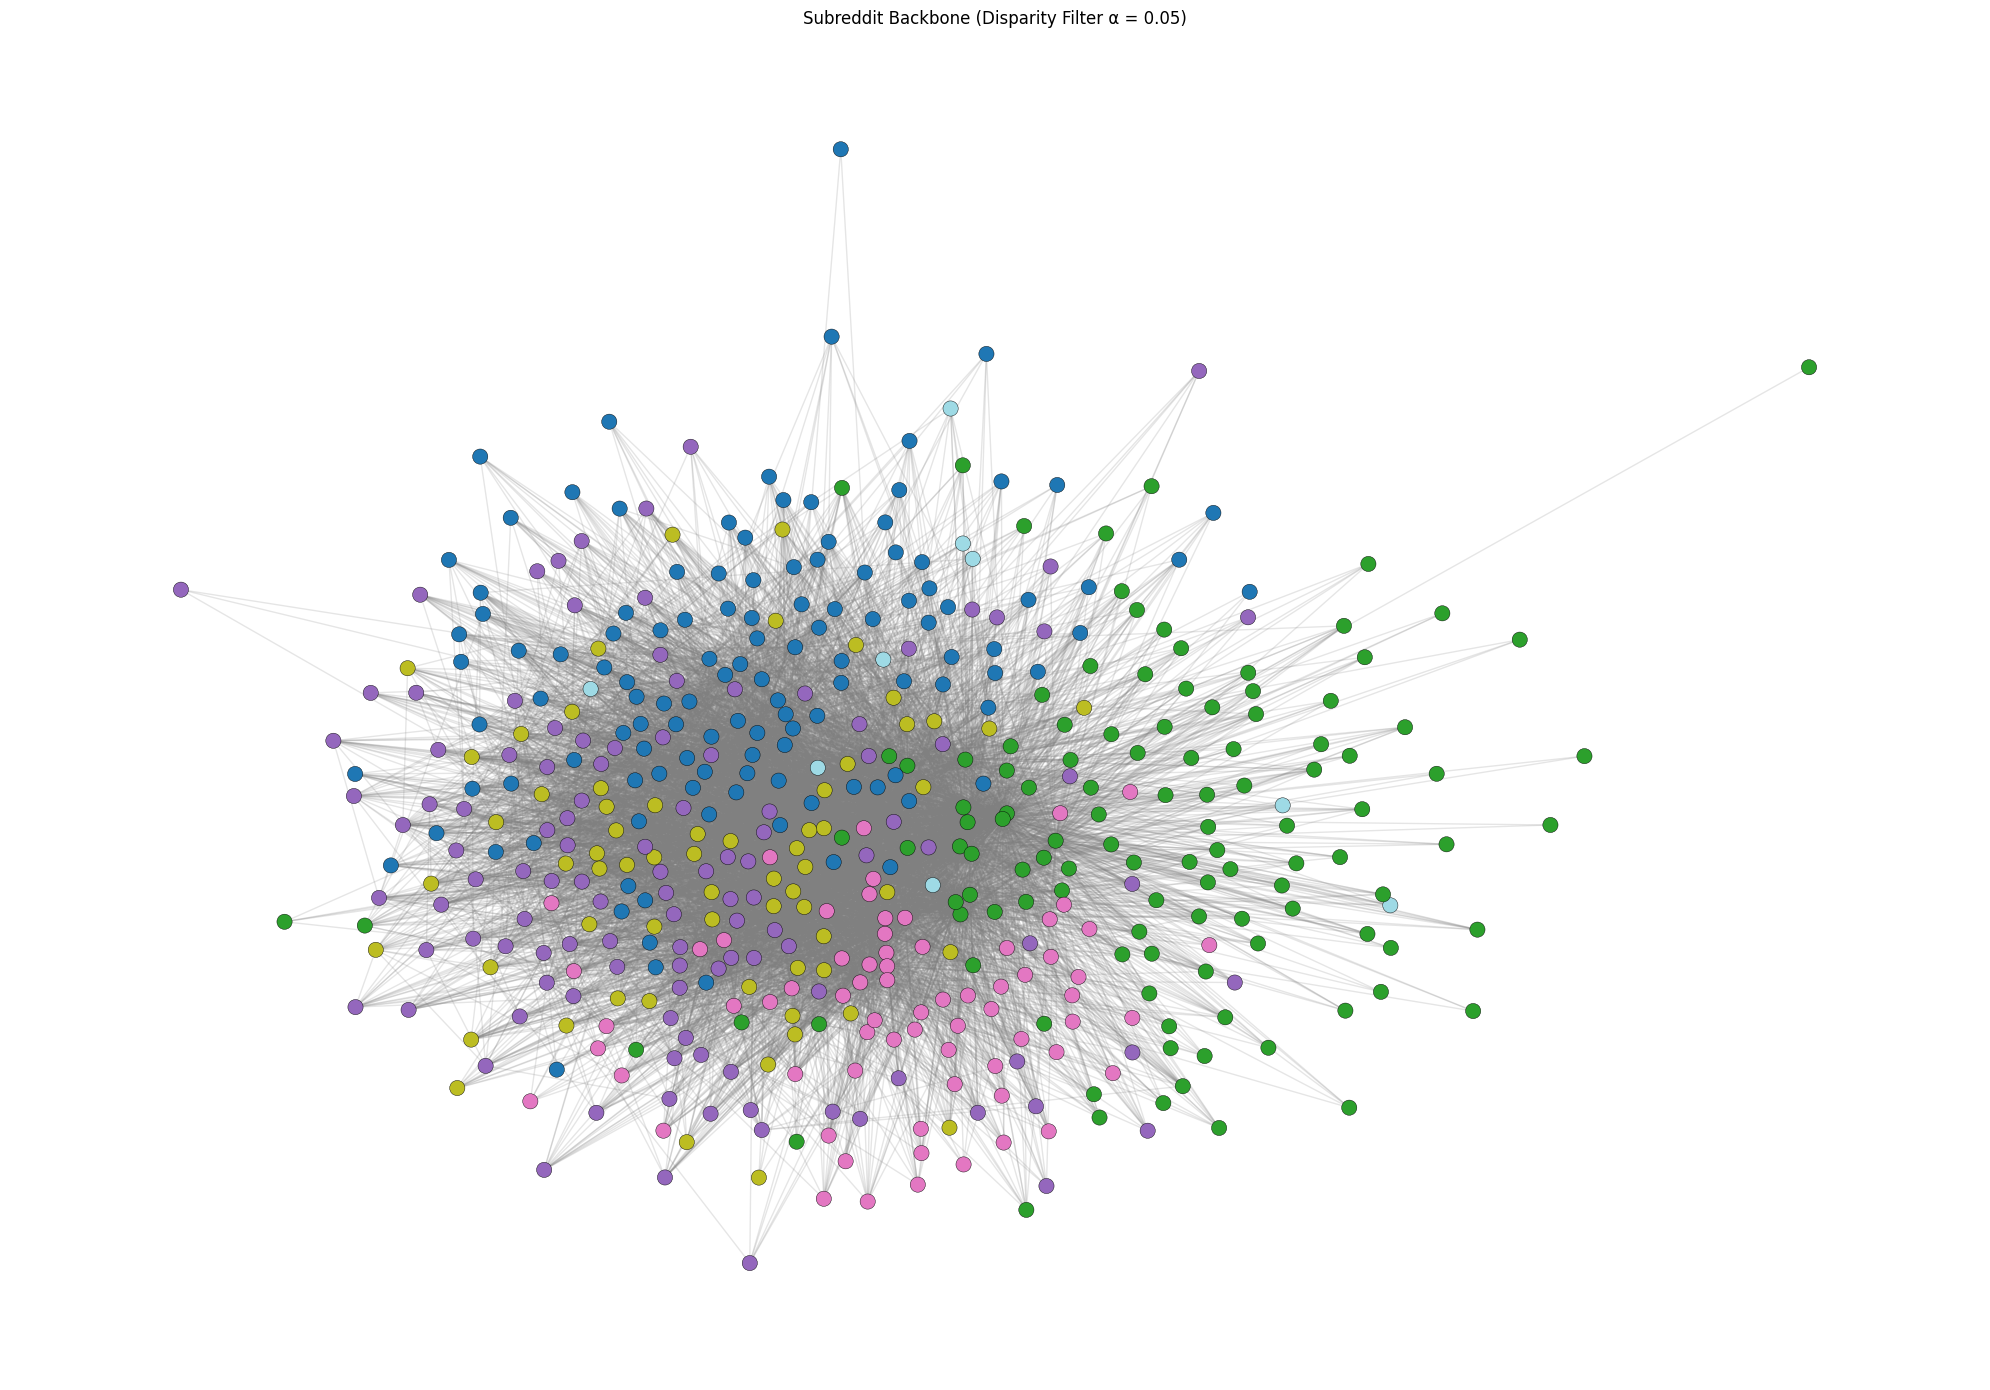

Final Graph Stats: 500 Nodes | 8455 Edges


In [106]:
# k controls the distance/repulsion between nodes
pos = nx.spring_layout(G_high_sig, k=0.35, iterations=200, seed=42)

plt.figure(figsize=(20, 14))

# create color map based on Louvain clusters / assign a unique integer ID to each cluster for the colormap
node_colors = []
for node in G_high_sig.nodes():
    for i, cluster in enumerate(clusters):
        if node in cluster:
            node_colors.append(i)
            break

# draw edges 
nx.draw_networkx_edges(G_high_sig, pos, alpha=0.2, edge_color='gray', width=1.0)

# draw nodes
nx.draw_networkx_nodes(
    G_high_sig, pos, 
    node_size=120, 
    node_color=node_colors, 
    cmap=plt.cm.tab20, 
    edgecolors='black', 
    linewidths=0.3
)

plt.title(f"Subreddit Backbone (Disparity Filter α = {ALPHA})")
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Final Graph Stats: {G_high_sig.number_of_nodes()} Nodes | {G_high_sig.number_of_edges()} Edges")

In [102]:
# Tribe Report
# calc deg centrality to find the "leaders" of each cluster
centrality = nx.degree_centrality(G_high_sig)

subreddit_list = numeric_matrix.columns

tribe_report = []

for i, cluster in enumerate(clusters):
    leader_node = max(cluster, key=lambda n: centrality[n]) # identify the leader
    
    # sort ALL members by centrality
    sorted_nodes = sorted(cluster, key=lambda n: centrality[n], reverse=True)
    
    # map indices back to names using the subreddit_list
    member_names = [f"r/{subreddit_list[node]}" for node in sorted_nodes]
    
    tribe_report.append({
        "Tribe": i + 1,
        "Leader": f"r/{subreddit_list[leader_node]}",
        "Size": len(cluster),
        "Main Members": ", ".join(member_names[:10]) + ("..." if len(member_names) > 10 else "")
    })

df_report = pd.DataFrame(tribe_report).sort_values(by="Size", ascending=False)
display(df_report) # Renders the DataFrame nicely in Jupyter

,Tribe,Leader,Size,Main Members
0,1,r/humor,123,"r/humor, r/minecraftmemes, r/metal, r/reallifedoodles, r/softwaregore, r/artporn, r/trippinthroughtime, r/bokunoheroacademia, r/onepunchman, r/gifrecipes..."
1,2,r/freeebooks,117,"r/freeebooks, r/animeart, r/algotrading, r/nft, r/wallpaper, r/savedyouaclick, r/recipes, r/15minutefood, r/healthyfood, r/artisanvideos..."
2,3,r/ethtrader,117,"r/ethtrader, r/spacex, r/standupshots, r/ethereum, r/astrophotography, r/graffiti, r/cryptomarkets, r/realestateinvesting, r/financialindependence, r/frugalmalefashion..."
3,4,r/asianbeauty,70,"r/asianbeauty, r/beautyguruchatter, r/mommit, r/xxfitness, r/iwantout, r/femalefashionadvice, r/astrology, r/kpop, r/javascript, r/europetravel..."
4,5,r/100yearsago,64,"r/100yearsago, r/makeup, r/nosleep, r/nails, r/makeupaddiction, r/journaling, r/sewing, r/awwducational, r/crochet, r/crafts..."
5,6,r/digitalpainting,9,"r/digitalpainting, r/machinelearning, r/valorant, r/foodhacks, r/artefactporn, r/edm, r/oldschoolcool, r/dundermifflin, r/europe"


In [101]:
# everything
tribe_report = []

for i, cluster in enumerate(clusters):
    leader_node = max(cluster, key=lambda n: centrality[n])
    
    # sort by centrality
    sorted_nodes = sorted(cluster, key=lambda n: centrality[n], reverse=True)
    
    # map indices to names
    member_names = [f"r/{subreddit_list[node]}" for node in sorted_nodes]
    
    tribe_report.append({
        "Tribe": i + 1,
        "Leader": f"r/{subreddit_list[leader_node]}",
        "Size": len(cluster),
        "Preview": ", ".join(member_names[:10]) + ("..." if len(member_names) > 10 else ""),
        "All Members": ", ".join(member_names)  # <--- This column captures the full list
    })

# convert to DataFrame
df_report = pd.DataFrame(tribe_report).sort_values(by="Size", ascending=False)

# not to truncate the text in the display
pd.set_option('display.max_colwidth', None)

# show the DataFrame
display(df_report)

,Tribe,Leader,Size,Preview,All Members
0,1,r/humor,123,"r/humor, r/minecraftmemes, r/metal, r/reallifedoodles, r/softwaregore, r/artporn, r/trippinthroughtime, r/bokunoheroacademia, r/onepunchman, r/gifrecipes...","r/humor, r/minecraftmemes, r/metal, r/reallifedoodles, r/softwaregore, r/artporn, r/trippinthroughtime, r/bokunoheroacademia, r/onepunchman, r/gifrecipes, r/highqualitygifs, r/writingprompts, r/youtubehaiku, r/pubattlegrounds, r/gamephysics, r/anime_irl, r/amd, r/hunterxhunter, r/hardware, r/deepintoyoutube, r/jujutsukaisen, r/getstudying, r/photoshopbattles, r/dogecoin, r/memeeconomy, r/nationalpark, r/cfb, r/realestate, r/philippines, r/teslamotors, r/campingandhiking, r/genshin_impact, r/askengineers, r/shingekinokyojin, r/animation, r/outdoors, r/worldbuilding, r/camping, r/roadtrip, r/homeowners, r/mlb, r/whatisit, r/survival, r/fauxmoi, r/law, r/stockmarket, r/abandonedporn, r/homeimprovement, r/naruto, r/homestead, r/earthporn, r/popculturechat, r/hbo, r/grilling, r/strangerthings, r/fishing, r/hiking, r/disneyplus, r/pixelart, r/solotravel, r/houseofthedragon, r/smallbusiness, r/bodybuilding, r/investing, r/slowcooking, r/backpacking, r/parenting, r/askwomen, r/urbanexploration, r/dogs, r/suggestmeabook, r/loseit, r/cscareerquestions, r/cookingforbeginners, r/twitch, r/aviation, r/woodworking, r/sidehustle, r/personalfinance, r/analog, r/aitah, r/electronicmusic, r/houseplants, r/nutrition, r/povertyfinance, r/mac, r/photography, r/teachers, r/cozyplaces, r/frugal, r/tattoodesigns, r/careerguidance, r/eatcheapandhealthy, r/college, r/cleaningtips, r/cooking, r/amioverreacting, r/travel, r/dating, r/getdisciplined, r/physics, r/askuk, r/vinyl, r/astronomy, r/health, r/lifehacks, r/netflixbestof, r/malefashionadvice, r/offmychest, r/casualuk, r/jobs, r/iphone, r/adulting, r/gardening, r/fantasy, r/coffee, r/legaladvice, r/psychology, r/selfimprovement, r/netflix, r/vegan, r/mademesmile, r/google"
1,2,r/freeebooks,117,"r/freeebooks, r/animeart, r/algotrading, r/nft, r/wallpaper, r/savedyouaclick, r/recipes, r/15minutefood, r/healthyfood, r/artisanvideos...","r/freeebooks, r/animeart, r/algotrading, r/nft, r/wallpaper, r/savedyouaclick, r/recipes, r/15minutefood, r/healthyfood, r/artisanvideos, r/mangacollectors, r/characterai, r/bollyblindsngossip, r/roblox, r/longdistance, r/relationshipmemes, r/baseball, r/indieheads, r/hockey, r/sciencememes, r/politicaldiscussion, r/mechanicadvice, r/onepiece, r/coronavirus, r/gadgets, r/rap, r/japantravel, r/latinopeopletwitter, r/apple, r/television, r/politics, r/futurology, r/canada, r/entertainment, r/nottheonion, r/guitar, r/whitepeopletwitter, r/boardgames, r/space, r/technology, r/baldursgate3, r/paranormal, r/expectationvsreality, r/wow, r/worldnews, r/spaceporn, r/historyporn, r/diy, r/internetisbeautiful, r/thelastairbender, r/weird, r/watches, r/funnyanimals, r/crappydesign, r/ufos, r/horror, r/anime, r/buyitforlife, r/tattoos, r/howto, r/contagiouslaughter, r/whatisthisthing, r/productivity, r/spotify, r/facepalm, r/dataisbeautiful, r/science, r/unpopularopinion, r/upliftingnews, r/tinder, r/humansbeingbros, r/chemistry, r/askhistorians, r/antiwork, r/changemyview, r/architecture, r/atheism, r/tifu, r/techsupport, r/movies, r/explainlikeimfive, r/books, r/news, r/scifi, r/todayilearned, r/mildlyinfuriating, r/lifeprotips, r/oddlyspecific, r/youshouldknow, r/pizza, r/adhd, r/australia, r/interestingasfuck, r/mapporn, r/mildlyinteresting, r/nostupidquestions, r/meirl, r/showerthoughts, r/biology, r/casualconversation, r/outoftheloop, r/itookapicture, r/wholesomememes, r/watchpeopledieinside, r/music, r/coolguides, r/damnthatsinteresting, r/cats, r/getmotivated, r/pics, r/chatgpt, r/malelivingspace, r/askscience, r/funny, r/beamazed, r/askreddit, r/aww"
2,3,r/ethtrader,117,"r/ethtrader, r/spacex, r/standupshots, r/ethereum, r/astrophotography, r/graffiti, r/cryptomarkets, r/realestateinvesting, r/financialindependence, r/frugalmalefashion...","r/ethtrader, r/space

### 4.3 Modularity

In [99]:
# Sanity Check 

# modularity score (how real are these tribes?)
# score > 0.3 means that clusters are statistically strong social structures.
mod_score = nx.community.modularity(G_high_sig, partition, weight='weight')

# network Density (hairball or ghost town)
# measures the ratio of actual edges to possible edges.
density = nx.density(G_high_sig)

# betweenness centrality (who are the actual gatekeepers)
# invert the weights - NetworkX expects distance (lower is closer)
# weights are 'similarity' (higher is closer).
for u, v, d in G_high_sig.edges(data=True):
    d['distance'] = 1.0 / (d['weight'] + 1e-6) #avoid division by zero 

# run the centrality using our new 'distance' metric
betweenness = nx.betweenness_centrality(G_high_sig, weight='distance')

# map the top 5 bridge nodes back to their names
top_bridges = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]
bridge_report = [
    {"Subreddit": f"r/{subreddit_list[node]}", "Bridge_Score": f"{score:.4f}"} 
    for node, score in top_bridges
]

# show
print("GLOBAL NETWORK SANITY CHECK")
print(f"Modularity Score: {mod_score:.4f}")
print(f"(Score > 0.3 = Excellent 'Tribe' structure)")
print(f"\nNetwork Density:  {density:.4f}")
print(f"(Range 0.03 - 0.08 = High-Signal 'Backbone' Map)")
print("\nTop 5 Bridge Subreddits (The Gatekeepers):")
for b in bridge_report:
    print(f"   {b['Subreddit']}: {b['Bridge_Score']}")

GLOBAL NETWORK SANITY CHECK
Modularity Score: 0.2502
(Score > 0.3 = Excellent 'Tribe' structure)

Network Density:  0.0678
(Range 0.03 - 0.08 = High-Signal 'Backbone' Map)

Top 5 Bridge Subreddits (The Gatekeepers):
   r/recipes: 0.0842
   r/15minutefood: 0.0750
   r/algotrading: 0.0738
   r/nft: 0.0595
   r/freeebooks: 0.0537


### 4.4 Clustering Coefficient

In [88]:
# Measures the "friend of a friend" probability.
# If Subreddit A is connected to Subreddit B, and Subreddit A is also connected to Subreddit C...
# how likely is it that B and C are connected to each other?
# high score -> tight-knit 
avg_clustering = nx.average_clustering(G_high_sig, weight='weight')

print(f"Average Clustering: {avg_clustering:.4f}")

Average Clustering: 0.0137
